# Tech Challenge — Classificação da Qualidade de Vinhos

## Objetivo

Desenvolver e comparar modelos de Machine Learning para classificar vinhos como **Alta Qualidade** quando `quality >= 7` e **Baixa/Média Qualidade** quando `quality < 7`.

A análise prioriza a identificação da classe minoritária — vinhos de alta qualidade — usando métricas adequadas a dados desbalanceados, como *recall*, F1-score, ROC-AUC e PR-AUC.


## 1. Bibliotecas e configurações

O projeto usa sementes aleatórias fixas para tornar os resultados reproduzíveis. Os gráficos e tabelas são salvos na pasta `results/`.


In [1]:
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# O notebook funciona tanto quando executado a partir da raiz do projeto quanto da pasta notebooks/.
data_candidates = [
    Path('data/WineQT.csv'),
    Path('../data/WineQT.csv'),
    Path('wine-quality-classification/data/WineQT.csv'),
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Arquivo WineQT.csv não encontrado. Coloque-o na pasta data/.')

results_candidates = [Path('results'), Path('../results'), Path('wine-quality-classification/results')]
results_dir = next((path for path in results_candidates if path.exists()), Path('results'))
results_dir.mkdir(parents=True, exist_ok=True)

print(f'Base utilizada: {data_path.resolve()}')
print(f'Resultados serão salvos em: {results_dir.resolve()}')

/usr/local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base utilizada: /home/user/conv_c0ca2489-e96a-46d4-b63c-33841315f95d/wine-quality-classification/data/WineQT.csv
Resultados serão salvos em: /home/user/conv_c0ca2489-e96a-46d4-b63c-33841315f95d/wine-quality-classification/results


## 2. Carga, qualidade dos dados e variável alvo

A coluna `Id` não representa uma característica físico-química e, por isso, é removida. Duplicidades exatas são removidas para evitar que a mesma observação seja contada mais de uma vez.


In [2]:
df = pd.read_csv(data_path)

if 'Id' in df.columns:
    df = df.drop(columns='Id')

missing_values = df.isna().sum()
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# Variável alvo binária definida pelo enunciado.
df['quality_label'] = (df['quality'] >= 7).astype(int)

quality_summary = pd.DataFrame({
    'Quantidade': df['quality_label'].value_counts().sort_index(),
    'Percentual': (df['quality_label'].value_counts(normalize=True).sort_index() * 100).round(2)
}, index=['Baixa/Média (<7)', 'Alta (>=7)'])

print('Valores ausentes por variável')
print(missing_values)
print(f'\nDuplicidades exatas removidas: {duplicate_rows}')
print(f'Formato final após limpeza: {df.shape}')
quality_summary

Valores ausentes por variável
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicidades exatas removidas: 125
Formato final após limpeza: (1018, 13)


,Quantidade,Percentual
Baixa/Média (<7),NaN,NaN
Alta (>=7),NaN,NaN


**Interpretação esperada.** A classe de alta qualidade é minoritária. Por isso, a acurácia isolada pode ser enganosa — um modelo que previsse sempre a classe majoritária teria uma acurácia alta, mas não identificaria vinhos de alta qualidade.


## 3. Análise Exploratória de Dados

Nesta etapa são analisados o balanceamento das classes, as distribuições, possíveis valores extremos e a relação entre as variáveis físico-químicas e a qualidade.


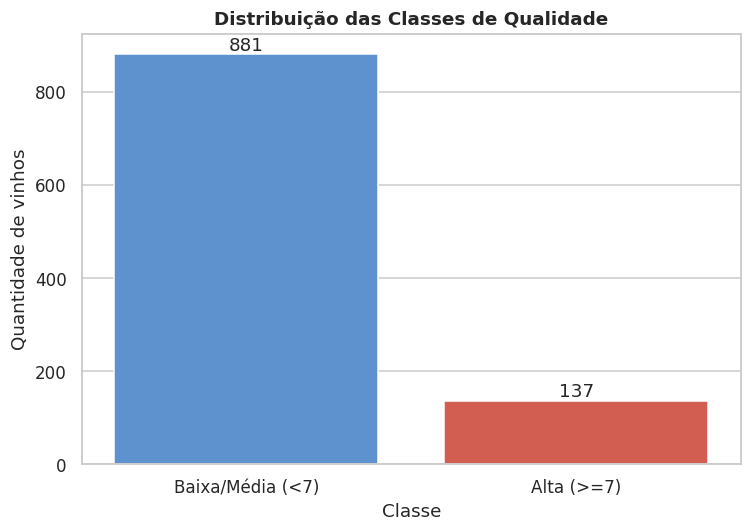

In [3]:
# Distribuição das classes
plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df,
    x='quality_label',
    hue='quality_label',
    palette=['#4A90E2', '#E74C3C'],
    legend=False,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Baixa/Média (<7)', 'Alta (>=7)'])
ax.set_title('Distribuição das Classes de Qualidade', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade de vinhos')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(results_dir / 'distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

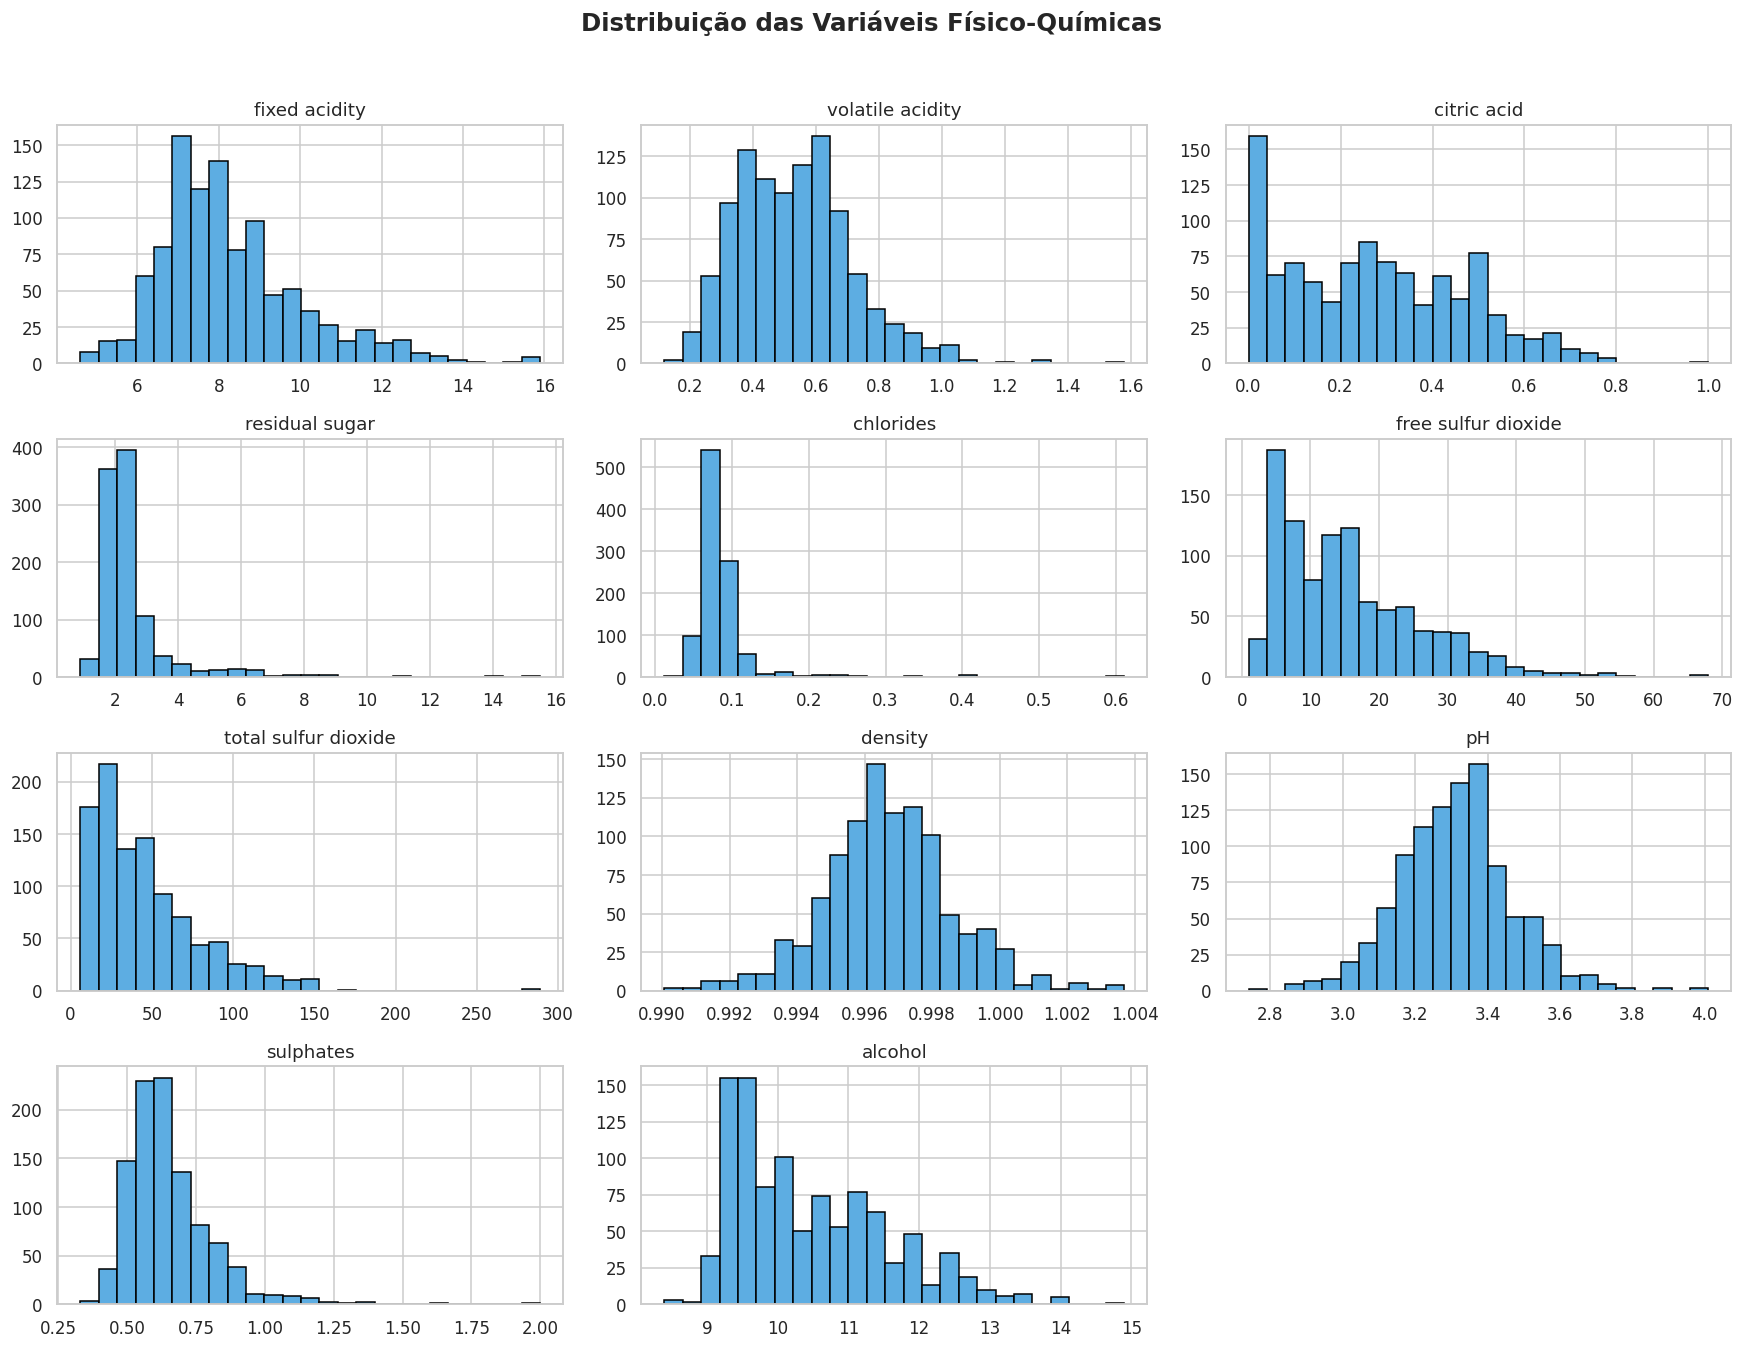

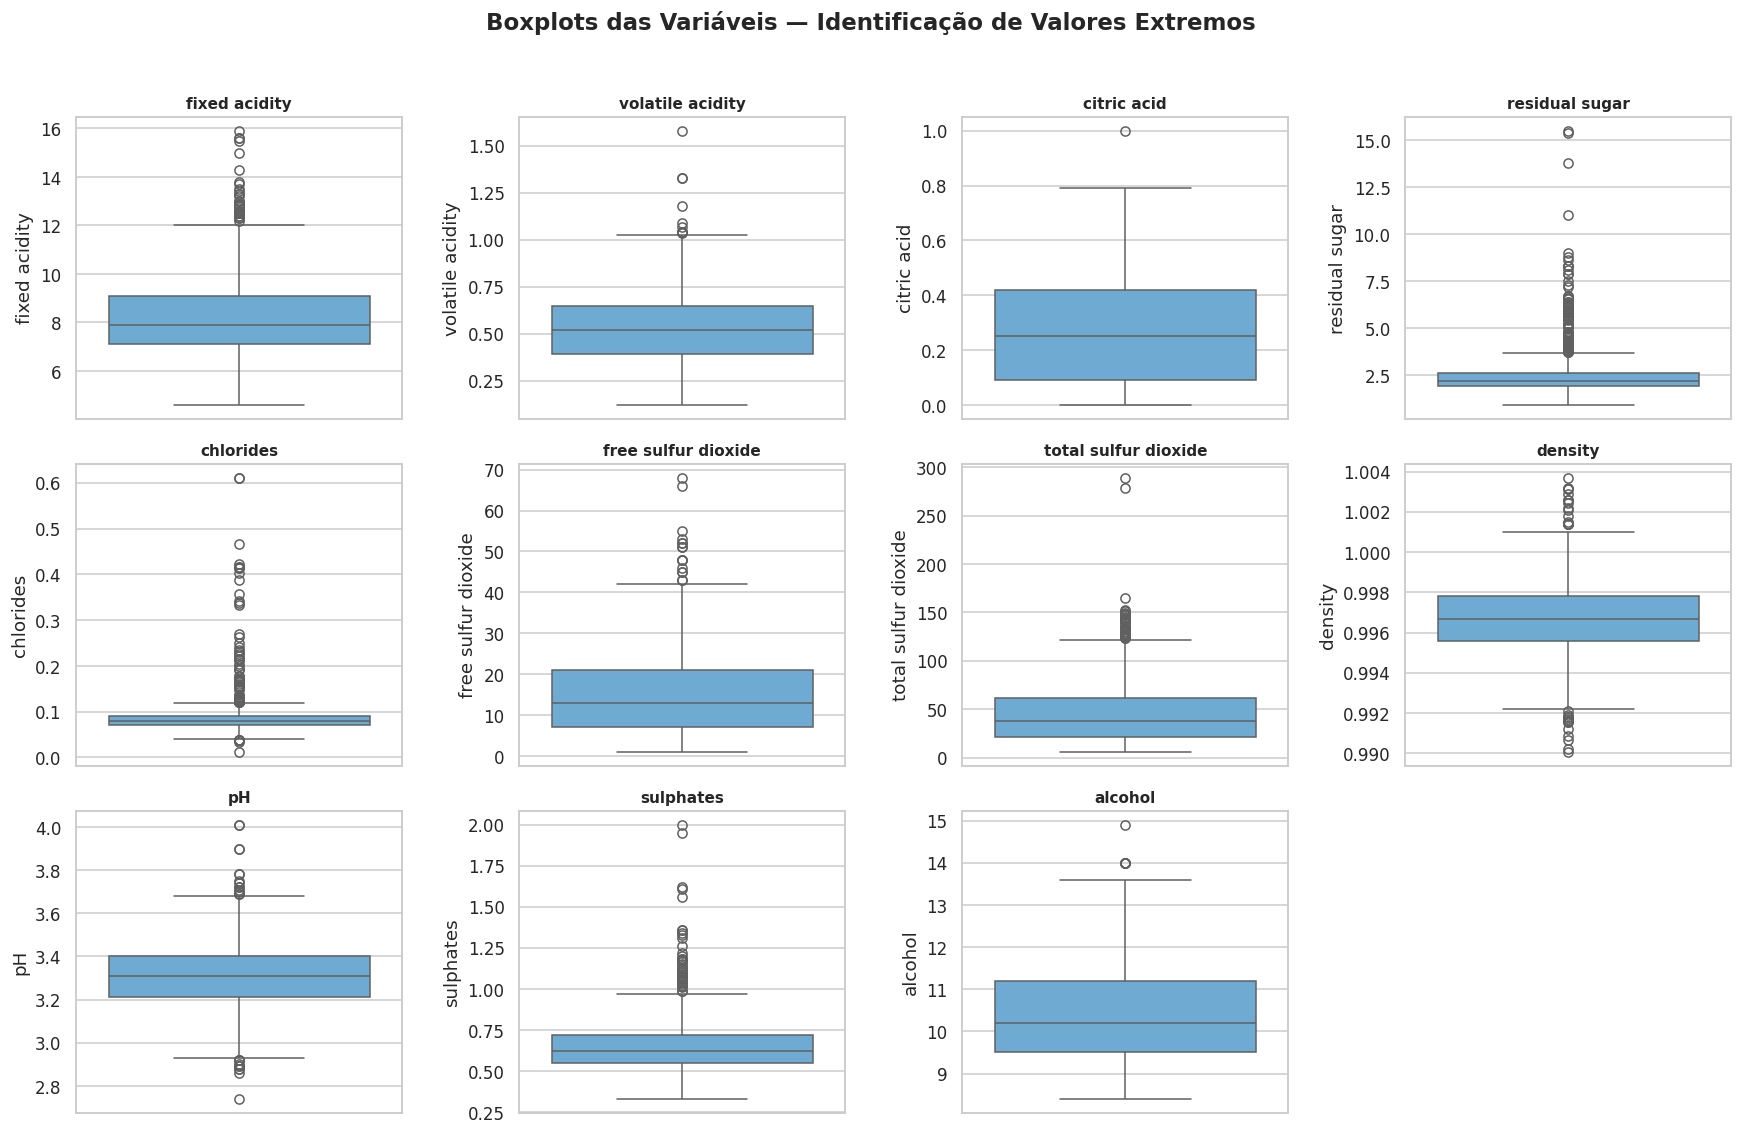

In [4]:
feature_columns = [
    column for column in df.columns
    if column not in ['quality', 'quality_label']
]

# Histogramas para investigar distribuição e assimetria.
df[feature_columns].hist(figsize=(16, 12), bins=25, edgecolor='black', color='#5DADE2')
plt.suptitle('Distribuição das Variáveis Físico-Químicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(results_dir / 'histogramas_variaveis.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplots para investigar possíveis outliers.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for axis, column in zip(axes.flat, feature_columns):
    sns.boxplot(y=df[column], color='#5DADE2', ax=axis)
    axis.set_title(column, fontsize=10, fontweight='bold')
for axis in axes.flat[len(feature_columns):]:
    axis.remove()
plt.suptitle('Boxplots das Variáveis — Identificação de Valores Extremos', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(results_dir / 'boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

**Decisão sobre outliers.** Valores extremos não são removidos automaticamente. Em dados de produção, eles podem representar variações químicas reais e ter valor preditivo. Modelos baseados em árvores também são menos sensíveis a escala e a extremos do que modelos lineares.


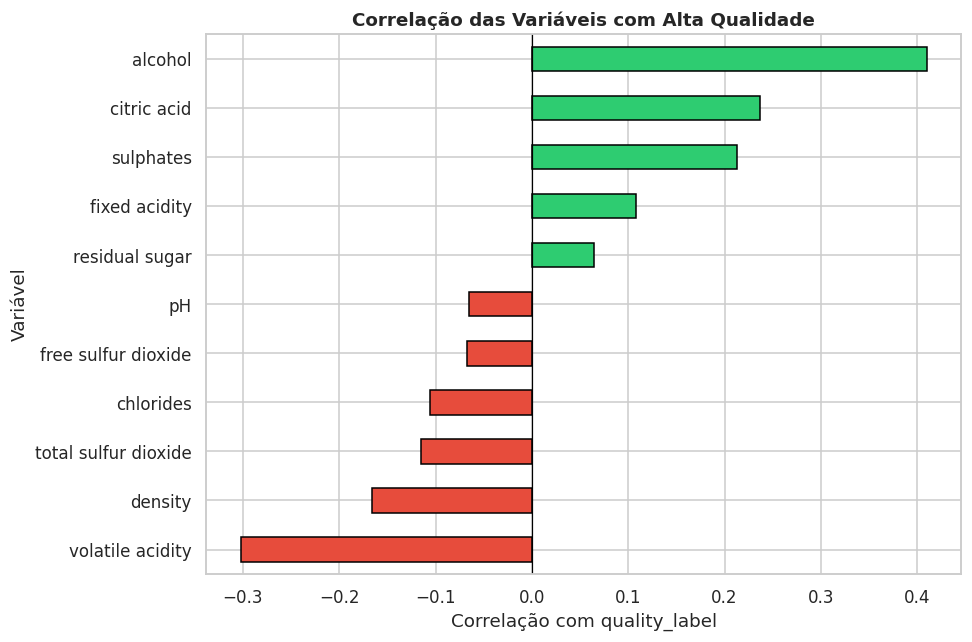

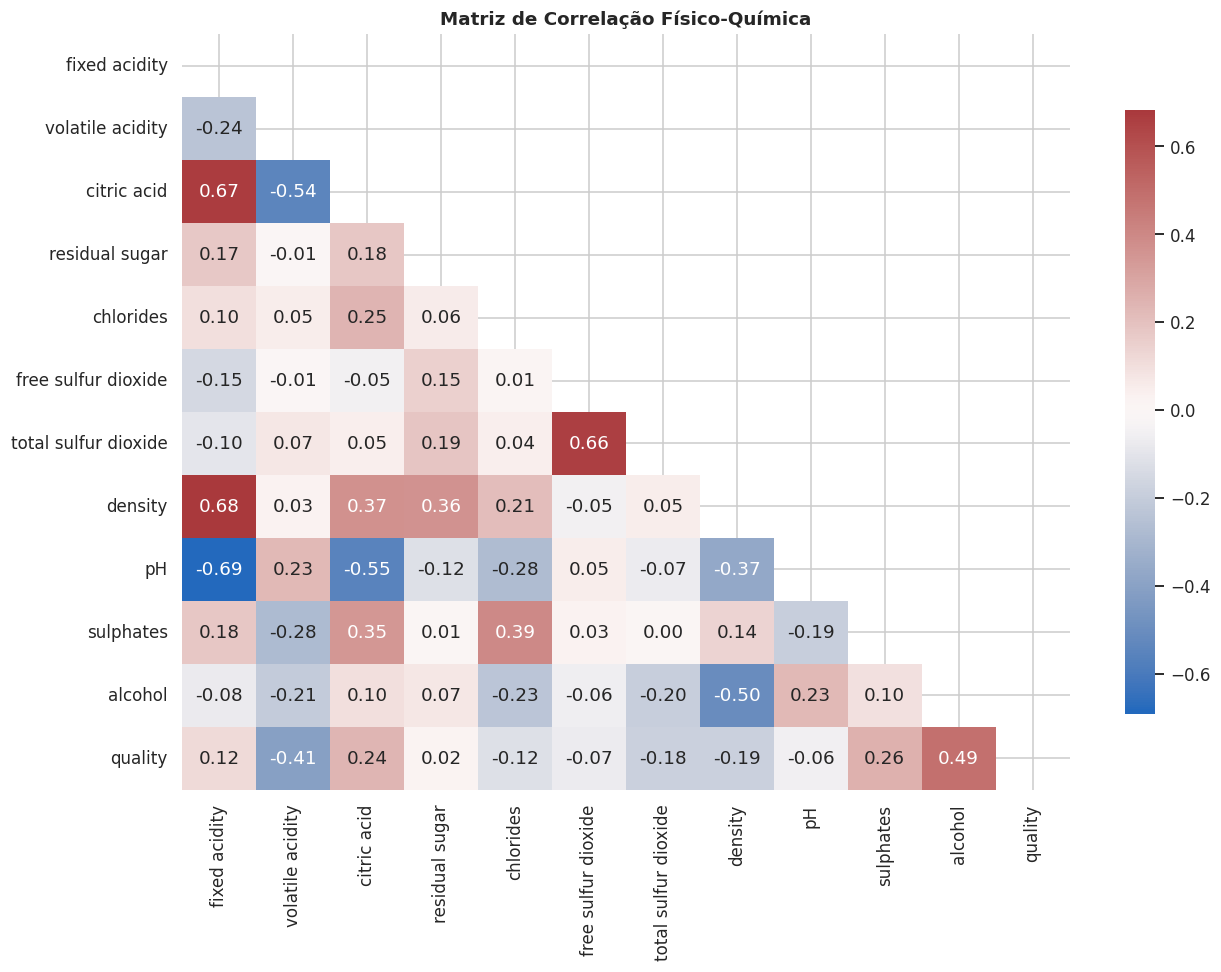

Variáveis mais positivamente associadas à alta qualidade
fixed acidity    0.108
sulphates        0.213
citric acid      0.237
alcohol          0.410
Name: quality_label, dtype: float64

Variáveis mais negativamente associadas à alta qualidade
volatile acidity       -0.302
density                -0.166
total sulfur dioxide   -0.115
chlorides              -0.106
Name: quality_label, dtype: float64


In [5]:
# Correlação das variáveis originais com o target.
correlation_target = (
    df.corr(numeric_only=True)['quality_label']
    .drop(['quality_label', 'quality'])
    .sort_values()
)

plt.figure(figsize=(9, 6))
colors = ['#E74C3C' if value < 0 else '#2ECC71' for value in correlation_target.values]
correlation_target.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação das Variáveis com Alta Qualidade', fontweight='bold')
plt.xlabel('Correlação com quality_label')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig(results_dir / 'correlacao_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Matriz completa, útil para identificar variáveis altamente relacionadas entre si.
plt.figure(figsize=(12, 9))
correlation_matrix = df.drop(columns='quality_label').corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='vlag', center=0, annot=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação Físico-Química', fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir / 'matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

print('Variáveis mais positivamente associadas à alta qualidade')
print(correlation_target.tail(4).round(3))
print('\nVariáveis mais negativamente associadas à alta qualidade')
print(correlation_target.head(4).round(3))

**Como interpretar.** Correlação indica associação, não causalidade. As variáveis mais associadas à qualidade podem ser usadas como indicadores para monitoramento do processo produtivo, mas não permitem concluir sozinhas que uma alteração causará melhoria na qualidade.


## 4. Feature engineering e divisão dos dados

São criadas relações químicas potencialmente relevantes. A separação treino/teste é estratificada para preservar a proporção da classe minoritária. A coluna `quality` é excluída das variáveis preditoras porque foi usada para criar o target — mantê-la causaria vazamento de dados.


In [6]:
# Variáveis derivadas a partir de relações químicas.
df['bound_sulfur_dioxide'] = df['total sulfur dioxide'] - df['free sulfur dioxide']
df['acidity_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-5)
df['free_sulfur_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)

X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    'Registros': [len(X_train), len(X_test)],
    'Alta qualidade (%)': [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]
}, index=['Treino', 'Teste'])

split_summary

,Registros,Alta qualidade (%)
Treino,763,13.50
Teste,255,13.33


## 5. Modelagem e validação cruzada

São comparados três modelos. A Regressão Logística usa padronização dentro de uma `Pipeline`; Random Forest e XGBoost recebem pesos para reduzir o efeito do desbalanceamento. A escolha do modelo é feita com validação cruzada estratificada no conjunto de treino, mantendo o conjunto de teste isolado para a avaliação final.


In [7]:
positive_class_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=positive_class_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

cv_rows = []
for model_name, model in tqdm(models.items(), desc='Validando modelos'):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_rows.append({
        'Modelo': model_name,
        'Acurácia média': scores['test_accuracy'].mean(),
        'Precisão média': scores['test_precision'].mean(),
        'Recall médio': scores['test_recall'].mean(),
        'F1 médio': scores['test_f1'].mean(),
        'ROC-AUC médio': scores['test_roc_auc'].mean(),
        'PR-AUC médio': scores['test_pr_auc'].mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(['F1 médio', 'PR-AUC médio'], ascending=False)
    .reset_index(drop=True)
    .round(3)
)

cv_results.to_csv(results_dir / 'validacao_cruzada_modelos.csv', index=False)
cv_results

Validando modelos:   0%|          | 0/3 [00:00<?, ?it/s]

Validando modelos:  33%|███▎      | 1/3 [00:01<00:03,  1.58s/it]

Validando modelos:  67%|██████▋   | 2/3 [00:03<00:01,  1.67s/it]

Validando modelos: 100%|██████████| 3/3 [00:03<00:00,  1.04s/it]

Validando modelos: 100%|██████████| 3/3 [00:03<00:00,  1.20s/it]

,Modelo,Acurácia média,Precisão média,Recall médio,F1 médio,ROC-AUC médio,PR-AUC médio
0,XGBoost,0.874,0.538,0.545,0.539,0.873,0.507
1,Regressão Logística,0.789,0.374,0.787,0.505,0.874,0.569
2,Random Forest,0.886,0.618,0.400,0.482,0.882,0.564


**Critério de seleção.** O F1-score equilibra precisão e recall na classe de alta qualidade. O PR-AUC é usado como critério de desempate por ser particularmente útil em classes desbalanceadas.


## 6. Otimização do threshold sem usar o teste

O limite padrão de probabilidade é 0,50. Aqui, ele é ajustado usando somente probabilidades *out-of-fold* do conjunto de treino. Isso evita escolher o threshold com base no conjunto de teste.


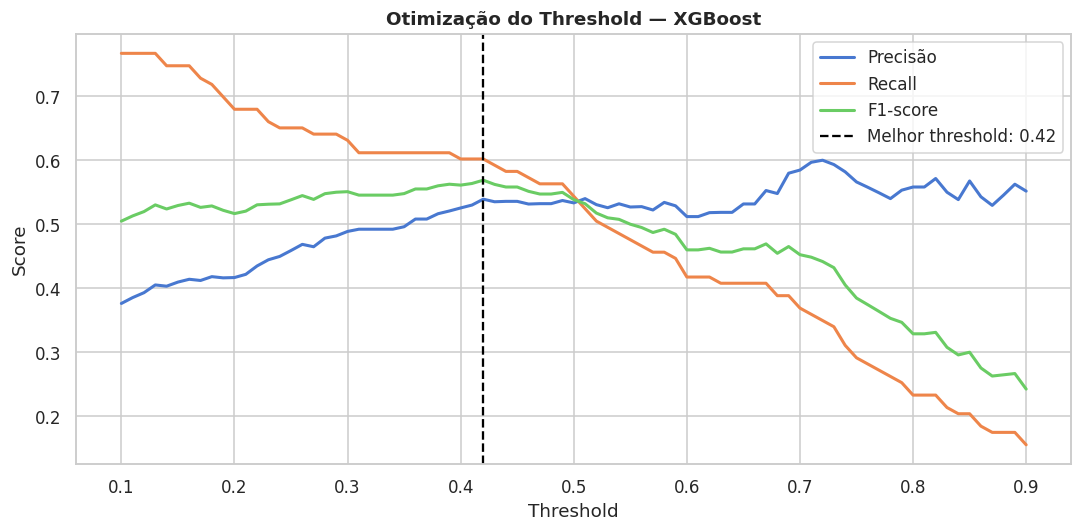

Modelo selecionado: XGBoost
Threshold selecionado pelo maior F1 no treino: 0.42


,Threshold,Precisão,Recall,F1-score
32,0.42,0.539,0.602,0.569


In [8]:
best_model_name = cv_results.iloc[0]['Modelo']
best_model = models[best_model_name]

# Probabilidades out-of-fold no treino para escolher o threshold sem vazamento.
y_train_oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    threshold_predictions = (y_train_oof_proba >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': round(float(threshold), 2),
        'Precisão': precision_score(y_train, threshold_predictions, zero_division=0),
        'Recall': recall_score(y_train, threshold_predictions, zero_division=0),
        'F1-score': f1_score(y_train, threshold_predictions, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results['F1-score'].idxmax()]
best_threshold = best_threshold_row['Threshold']

plt.figure(figsize=(10, 5))
for metric_name in ['Precisão', 'Recall', 'F1-score']:
    plt.plot(threshold_results['Threshold'], threshold_results[metric_name], label=metric_name, linewidth=2)
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Melhor threshold: {best_threshold:.2f}')
plt.title(f'Otimização do Threshold — {best_model_name}', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / 'otimizacao_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Modelo selecionado: {best_model_name}')
print(f'Threshold selecionado pelo maior F1 no treino: {best_threshold:.2f}')
best_threshold_row.to_frame().T.round(3)

## 7. Avaliação final no conjunto de teste

Após a escolha do modelo e do threshold usando somente o treino, o desempenho é avaliado uma única vez em dados não vistos.


In [9]:
best_model.fit(X_train, y_train)
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred_default = (y_test_proba >= 0.50).astype(int)
y_test_pred_optimized = (y_test_proba >= best_threshold).astype(int)

final_metrics = pd.DataFrame([
    {
        'Cenário': 'Threshold padrão (0,50)',
        'Acurácia': accuracy_score(y_test, y_test_pred_default),
        'Precisão': precision_score(y_test, y_test_pred_default, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred_default, zero_division=0),
        'F1-score': f1_score(y_test, y_test_pred_default, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_test_proba),
        'PR-AUC': average_precision_score(y_test, y_test_proba),
    },
    {
        'Cenário': f'Threshold otimizado ({best_threshold:.2f})',
        'Acurácia': accuracy_score(y_test, y_test_pred_optimized),
        'Precisão': precision_score(y_test, y_test_pred_optimized, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred_optimized, zero_division=0),
        'F1-score': f1_score(y_test, y_test_pred_optimized, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_test_proba),
        'PR-AUC': average_precision_score(y_test, y_test_proba),
    },
]).round(3)

final_metrics.to_csv(results_dir / 'metricas_finais_teste.csv', index=False)
final_metrics

,Cenário,Acurácia,Precisão,Recall,F1-score,ROC-AUC,PR-AUC
0,"Threshold padrão (0,50)",0.890,0.583,0.618,0.600,0.915,0.634
1,Threshold otimizado (0.42),0.878,0.538,0.618,0.575,0.915,0.634


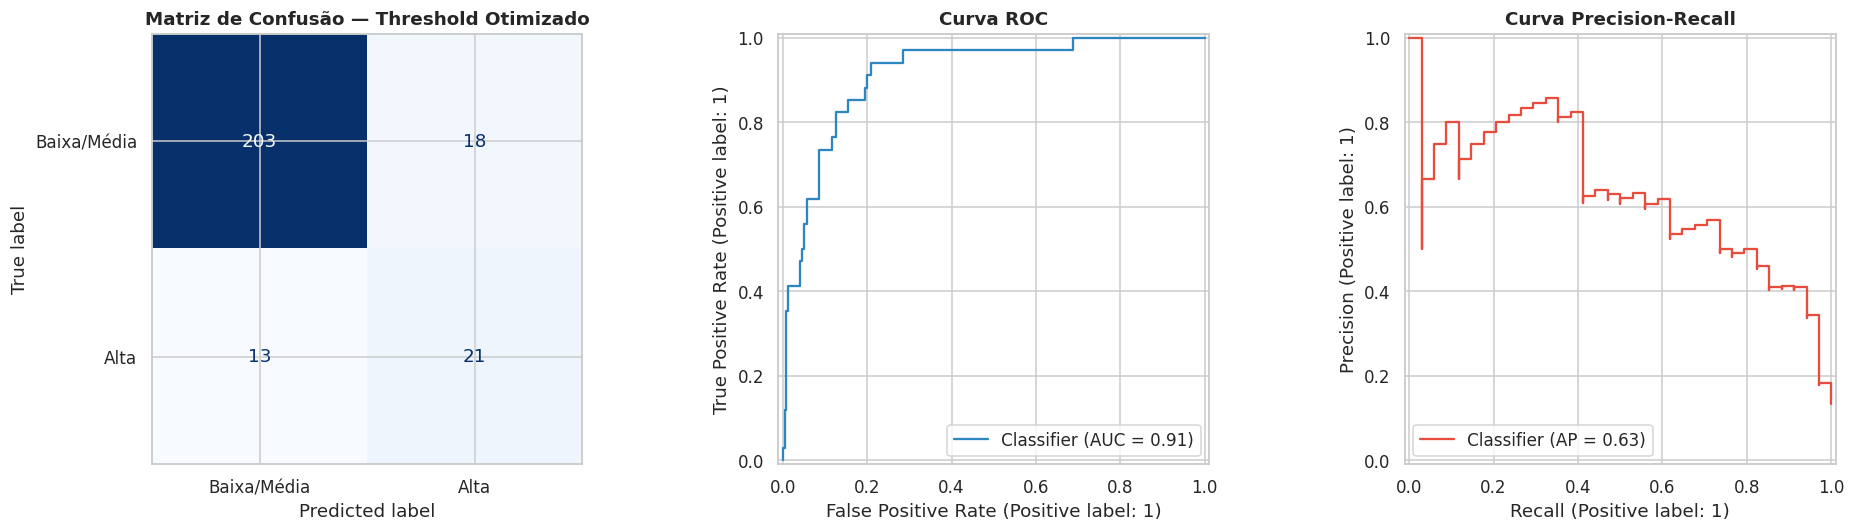

Relatório de classificação com threshold otimizado
                precision    recall  f1-score   support

   Baixa/Média       0.94      0.92      0.93       221
Alta Qualidade       0.54      0.62      0.58        34

      accuracy                           0.88       255
     macro avg       0.74      0.77      0.75       255
  weighted avg       0.89      0.88      0.88       255



In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_optimized,
    display_labels=['Baixa/Média', 'Alta'],
    cmap='Blues',
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title('Matriz de Confusão — Threshold Otimizado', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_test_proba, color='#2E86C1', ax=axes[1])
axes[1].set_title('Curva ROC', fontweight='bold')

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, color='#E74C3C', ax=axes[2])
axes[2].set_title('Curva Precision-Recall', fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / 'avaliacao_final_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

print('Relatório de classificação com threshold otimizado')
print(classification_report(y_test, y_test_pred_optimized, target_names=['Baixa/Média', 'Alta Qualidade'], zero_division=0))

## 8. Interpretação das variáveis

A importância por permutação mede a queda de desempenho quando os valores de uma variável são embaralhados. Ela funciona para qualquer modelo e deve ser interpretada como importância preditiva, não como evidência de causalidade.


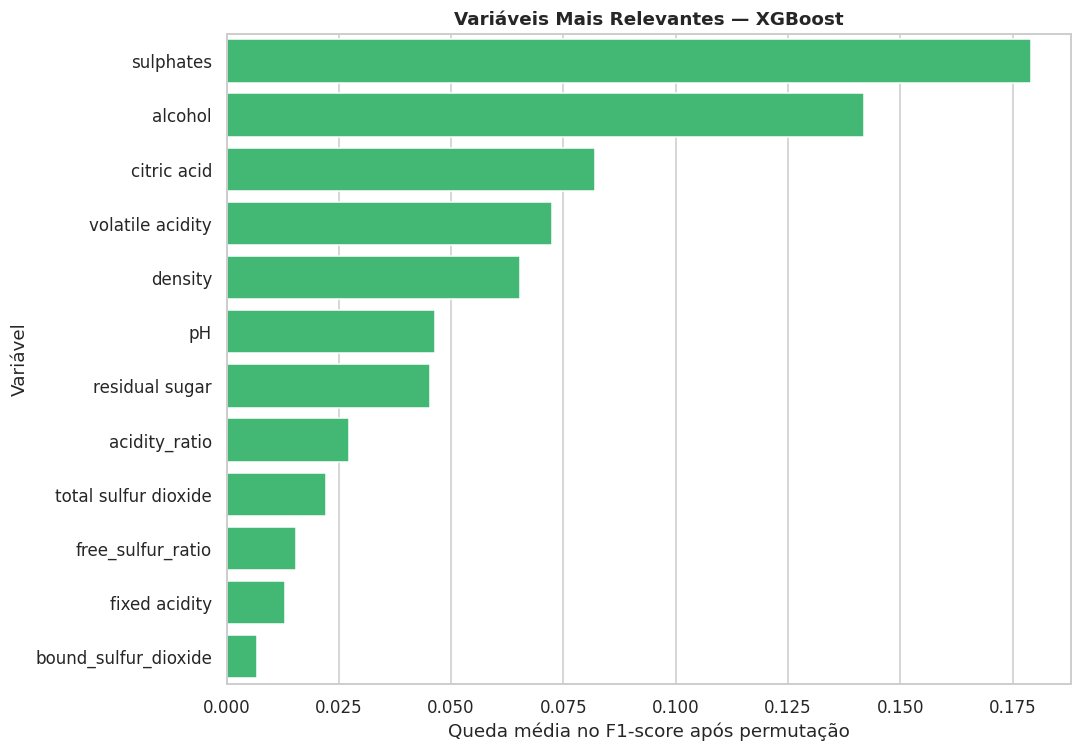

,Variável,Importância média (F1),Desvio padrão
0,sulphates,0.1792,0.0577
1,alcohol,0.1419,0.0436
2,citric acid,0.0821,0.0224
3,volatile acidity,0.0726,0.0372
4,density,0.0653,0.0324
5,pH,0.0465,0.0182
6,residual sugar,0.0454,0.0336
7,acidity_ratio,0.0272,0.0382
8,total sulfur dioxide,0.0221,0.0260
9,free_sulfur_ratio,0.0154,0.0352


In [11]:
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame({
        'Variável': X.columns,
        'Importância média (F1)': permutation_result.importances_mean,
        'Desvio padrão': permutation_result.importances_std,
    })
    .sort_values('Importância média (F1)', ascending=False)
    .reset_index(drop=True)
)

feature_importance.to_csv(results_dir / 'importancia_por_permutacao.csv', index=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(12),
    x='Importância média (F1)',
    y='Variável',
    color='#2ECC71',
)
plt.title(f'Variáveis Mais Relevantes — {best_model_name}', fontweight='bold')
plt.xlabel('Queda média no F1-score após permutação')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig(results_dir / 'importancia_variaveis.png', dpi=300, bbox_inches='tight')
plt.show()

feature_importance.head(12).round(4)

## 9. Conclusão executiva

O modelo selecionado deve ser usado como ferramenta de apoio à decisão, e não como substituto da avaliação sensorial. As variáveis com maior importância preditiva podem orientar o monitoramento do processo produtivo e ajudar a priorizar lotes com maior potencial de alta qualidade.

Como a classe de alta qualidade é minoritária, o desempenho deve ser acompanhado principalmente por recall, precisão, F1-score e PR-AUC. O threshold pode ser ajustado conforme a estratégia da vinícola: priorizar recall reduz o risco de deixar passar bons vinhos, enquanto priorizar precisão reduz falsos positivos.
